In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

In [6]:
df=pd.read_csv("Salary_dataset.csv")

In [7]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [3]:
X=df.iloc[:,0].values.reshape(-1,1)
y=df.iloc[:,1].values

In [4]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

In [5]:
model=SGDRegressor(
    max_iter=2000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

In [10]:
model.fit(x_scaled,y)

SGDRegressor(learning_rate='constant', max_iter=2000, random_state=42)

In [19]:
m=model.coef_[0]
b=model.intercept_[0]

In [24]:
print("Slope : ",m)
print("Intercept : ",b)

Slope :  2.7501488621569967
Intercept :  5.406004814946711


In [22]:
m_original=m/scaler.scale_[0]
b_original=b-(m*scaler.mean_[0]/scaler.scale_[0])

In [23]:
print("Original Sclope : ",m_original)
print("Original Intercept : ",b_original)

Original Sclope :  0.31773640646204504
Original Intercept :  0.7988269212470582


# VIZUALIZATION

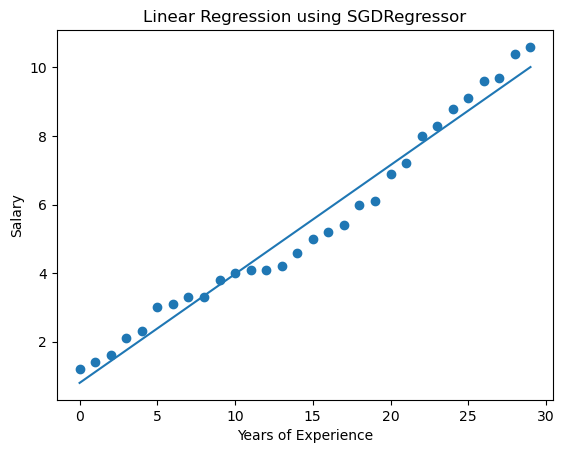

In [26]:
plt.scatter(X, y)
plt.plot(X, m_original * X + b_original)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression using SGDRegressor")
plt.show()
